# NFL Team Success: Predicting Season-Level Outcomes Using Multi-Source Data
**Authors:** Seth Phillips | Brittany Fetterman | Ethan Stanks  
**Date:** April 2026

---

## Project Overview

This notebook implements a full machine learning pipeline to predict NFL team season wins (2015–2025). Rather than focusing on individual game or play-level outcomes, the dominant approach in existing literature. This project addresses the understudied question of **what drives sustained, season-long team success**.

We integrate seven data sources from `nfl_data_py` (play-by-play, seasonal stats, rosters, injuries, draft picks, schedules, and win totals) into a unified season-level dataset, then apply and compare five modeling approaches ranging from linear regression to LSTM neural networks.

### Research Gap Addressed
As established in our literature review (Brown et al., 2022; Johnson & Lee, 2020; Smith et al., 2021), existing NFL analytics models predominantly focus on single-game or play-level predictions. This project directly addresses the gap by building a longitudinal, multi-source model that predicts **total season wins** — a comprehensive measure of team success.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **1. Environment Setup** | Import libraries, set global config |
| **2. Data Collection** | Pull all 7 data sources via `nfl_data_py` |
| **3. Data Preprocessing** | Clean, merge, handle missing values |
| **4. Feature Engineering** | Aggregate play-by-play → season level, create derived features |
| **5. Exploratory Data Analysis** | Summary statistics, distributions, correlations |
| **6. Modeling Pipeline** | Train/test split, scaling, encoding |
| **7. Models** | Linear Regression, Random Forest, XGBoost, MLP, LSTM/GRU |
| **8. Evaluation & Comparison** | MSE, R², feature importance |
| **9. Conclusions** | Key findings, limitations, next steps |

---
## Section 1: Environment Setup

In [1]:
# ─────────────────────────────────────────────
# 1.1  Standard Library & Data Manipulation
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ─────────────────────────────────────────────
# 1.2  Visualization
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ─────────────────────────────────────────────
# 1.3  NFL Data
# ─────────────────────────────────────────────
import nfl_data_py as nfl

# ─────────────────────────────────────────────
# 1.4  Scikit-Learn: Preprocessing & Models
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ─────────────────────────────────────────────
# 1.5  Gradient Boosting
# ─────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ─────────────────────────────────────────────
# 1.6  Deep Learning (PyTorch)
# ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ─────────────────────────────────────────────
# 1.7  Interpretability
# ─────────────────────────────────────────────
import shap

# ─────────────────────────────────────────────
# 1.8  Utilities
# ─────────────────────────────────────────────
from tqdm import tqdm
import os, random

# ─────────────────────────────────────────────
# 1.9  Reproducibility Seed
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set device for PyTorch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')       # Windows/Linux with NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')        # Apple Silicon Mac
else:
    DEVICE = torch.device('cpu')        # Any computer, no GPU

print(f'All libraries loaded successfully')
print(f'PyTorch device: {DEVICE}')
print(f'nfl_data_py version: {nfl.__version__ if hasattr(nfl, "__version__") else "installed"}')

✅ All libraries loaded successfully
🔧 PyTorch device: mps
📦 nfl_data_py version: installed


---
## Section 2: Data Collection

We pull seven data sources from `nfl_data_py` covering the 2015–2026 NFL seasons (10 full seasons). Each source contributes a distinct dimension of team context:

| Source | What it captures |
|--------|------------------|
| `import_seasonal_data` | Per-player seasonal stats (offense/defense) |
| `import_pbp_data` | Every play (aggregated to season level) |
| `import_seasonal_rosters` | Roster composition per team/season |
| `import_injuries` | Weekly injury reports |
| `import_draft_picks` | Draft investment and pick values |
| `import_schedules` | Strength of schedule |
| `import_win_totals` | Vegas win total lines (ground truth + market baseline) |

In [4]:
# ─────────────────────────────────────────────
# 2.1  Define year range
# ─────────────────────────────────────────────
YEARS = list(range(2015, 2025))   # 2015 through 2026 inclusive
print(f'Pulling data for {len(YEARS)} seasons: {YEARS[0]}–{YEARS[-1]}')

Pulling data for 10 seasons: 2015–2024


In [7]:
# ─────────────────────────────────────────────
# 2.2  Seasonal Player Stats
# Used for: offensive/defensive efficiency metrics
# ─────────────────────────────────────────────
print('Loading seasonal data')
seasonal_raw = nfl.import_seasonal_data(YEARS)
print(f'  → {seasonal_raw.shape[0]:,} rows | {seasonal_raw.shape[1]} columns')
seasonal_raw.head(3)

Loading seasonal data
  → 6,098 rows | 58 columns


,player_id,season,season_type,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,...,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr_x,special_teams_tds,fantasy_points,fantasy_points_ppr,games,tgt_sh,ay_sh,yac_sh,wopr_y,ry_sh,rtd_sh,rfd_sh,rtdfd_sh,dom,w8dom,yptmpa,ppr_sh
0,00-0007091,2015,REG,156,256,1690.000,9,5.000,16.000,101.000,3,2,1900.000,779.000,85.000,-0.113,0,7.422,0.532,16,15.000,0,0.000,0.000,2.000,...,0.000,0.000,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,91.100,91.100,8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.160
1,00-0010346,2015,REG,198,331,2249.000,9,17.000,16.000,95.000,1,0,3112.000,967.000,110.000,-31.957,0,7.325,0.516,6,-6.000,0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,91.360,91.360,10,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.113
2,00-0018227,2015,REG,0,0,0.000,0,0.000,0.000,0.000,0,0,0.000,0.000,0.000,0.000,0,0.000,0.000,1,-3.000,0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,-0.300,-0.300,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.004


In [8]:
# ─────────────────────────────────────────────
# 2.3  Play-by-Play Data (memory-efficient aggregation)
# Strategy: load one season → aggregate → discard raw rows → repeat
# This directly addresses the professor's feasibility concern.
# ─────────────────────────────────────────────

pbp_agg_list = []  # will hold one aggregated row per team per season

# Columns we actually need from the massive PBP dataset
PBP_COLS = [
    'season', 'posteam', 'defteam',
    'yards_gained', 'pass_attempt', 'rush_attempt',
    'complete_pass', 'interception', 'fumble',
    'sack', 'touchdown', 'field_goal_attempt',
    'field_goal_result', 'epa', 'wpa',
    'air_yards', 'yards_after_catch',
    'first_down', 'fourth_down_converted',
    'penalty', 'penalty_yards'
]

print('Aggregating play-by-play data (one season at a time)')

for year in tqdm(YEARS, desc='PBP seasons'):
    # Load one season at a time
    pbp_year = nfl.import_pbp_data([year], include_participation=False)

    # Keep only columns we need (reduces memory immediately)
    cols_present = [c for c in PBP_COLS if c in pbp_year.columns]
    pbp_year = pbp_year[cols_present].copy()

    # ── Offensive aggregation (grouped by posteam) ──
    off = pbp_year.groupby(['season', 'posteam']).agg(
        total_yards        = ('yards_gained',        'sum'),
        pass_attempts      = ('pass_attempt',         'sum'),
        rush_attempts      = ('rush_attempt',         'sum'),
        completions        = ('complete_pass',        'sum'),
        interceptions_thrown = ('interception',       'sum'),
        fumbles            = ('fumble',               'sum'),
        touchdowns_off     = ('touchdown',            'sum'),
        off_epa_per_play   = ('epa',                  'mean'),
        off_wpa            = ('wpa',                  'sum'),
        air_yards_total    = ('air_yards',            'sum'),
        yac_total          = ('yards_after_catch',    'sum'),
        first_downs        = ('first_down',           'sum'),
        fourth_down_conv   = ('fourth_down_converted','sum'),
        penalties_off      = ('penalty',              'sum'),
        penalty_yards_off  = ('penalty_yards',        'sum'),
    ).reset_index().rename(columns={'posteam': 'team'})

    # ── Defensive aggregation (grouped by defteam) ──
    def_ = pbp_year.groupby(['season', 'defteam']).agg(
        sacks              = ('sack',                 'sum'),
        def_epa_per_play   = ('epa',                  'mean'),
        interceptions_def  = ('interception',         'sum'),
    ).reset_index().rename(columns={'defteam': 'team'})

    # Merge offense and defense for this season
    season_pbp = off.merge(def_, on=['season', 'team'], how='outer')
    pbp_agg_list.append(season_pbp)

    # Free memory immediately
    del pbp_year

# Stack all seasons
pbp_agg = pd.concat(pbp_agg_list, ignore_index=True)
print(f'\nPBP aggregation complete: {pbp_agg.shape[0]} team-season rows')
pbp_agg.head(3)

Aggregating play-by-play data (one season at a time)


PBP seasons:   0%|                                       | 0/10 [00:00<?, ?it/s]

2015 done.
Downcasting floats.


PBP seasons:  10%|███                            | 1/10 [00:01<00:17,  1.96s/it]

2016 done.
Downcasting floats.


...

PBP seasons:  90%|███████████████████████████▉   | 9/10 [01:58<00:04,  4.75s/it]

2024 done.
Downcasting floats.


PBP seasons: 100%|██████████████████████████████| 10/10 [02:00<00:00, 12.06s/it]


 PBP aggregation complete: 320 team-season rows


,season,team,total_yards,pass_attempts,rush_attempts,completions,interceptions_thrown,fumbles,touchdowns_off,off_epa_per_play,off_wpa,air_yards_total,yac_total,first_downs,fourth_down_conv,penalties_off,penalty_yards_off,sacks,def_epa_per_play,interceptions_def
0,2015,ARI,7190.000,677.000,488.000,401.000,19.000,22.000,59.000,0.059,5.239,6955.000,2057.000,411.000,7.000,126.000,1170.000,38.000,-0.051,21.000
1,2015,ATL,5987.000,655.000,421.000,410.000,17.000,26.000,37.000,-0.016,0.543,4788.000,1856.000,355.000,10.000,103.000,845.000,19.000,-0.009,15.000
2,2015,BAL,5751.000,703.000,384.000,426.000,21.000,16.000,34.000,-0.043,-1.331,5083.000,2128.000,322.000,12.000,100.000,809.000,37.000,0.015,6.000


In [9]:
# ─────────────────────────────────────────────
# 2.4  Rosters
# Used for: roster depth, experience, positional composition
# ─────────────────────────────────────────────
print('Loading seasonal rosters')
rosters_raw = nfl.import_seasonal_rosters(YEARS)
print(f'  → {rosters_raw.shape[0]:,} rows | {rosters_raw.shape[1]} columns')
rosters_raw.head(3)

Loading seasonal rosters
  → 30,050 rows | 37 columns


,season,team,position,depth_chart_position,jersey_number,status,player_name,first_name,last_name,birth_date,height,weight,college,player_id,espn_id,sportradar_id,yahoo_id,rotowire_id,pff_id,pfr_id,fantasy_data_id,sleeper_id,years_exp,headshot_url,ngs_position,week,game_type,status_description_abbr,football_name,esb_id,gsis_it_id,smart_id,entry_year,rookie_year,draft_club,draft_number,age
0,2015,SF,K,None,9,ACT,Phil Dawson,Philip,Dawson,1975-01-23,71.000,200.000,Texas,00-0004091,1440,e5247e5f-c4af-4a9b-8c7c-da75ef7fbf8d,4269,994,422,None,5714,229,17.000,https://static.www.nfl.com/image/private/f_aut...,None,17,REG,A01,Phil,DAW705989,23860,32004441-5770-5989-ac23-bf6cdafcb988,1998.000,1998.000,None,None,40.000
1,2015,IND,QB,None,8,ACT,Matt Hasselbeck,Matthew,Hasselbeck,1975-09-25,76.000,235.000,Boston College,00-0007091,1575,7d8eba61-208d-4d91-86cd-704ad05cb7f4,4416,949,408,HassMa00,1034,36,17.000,https://static.www.nfl.com/image/private/f_aut...,None,17,REG,I01,Matt,HAS536799,23636,32004841-5353-6799-a37b-f4bab15e4312,1998.000,1998.000,GB,187,39.000
2,2015,DEN,QB,None,18,ACT,Peyton Manning,Peyton,Manning,1976-03-24,77.000,230.000,Tennessee,00-0010346,1428,aae6d92e-5f28-43ee-b0dc-522e80e99f76,4256,902,327,MannPe00,7328,294,17.000,https://static.www.nfl.com/image/private/f_aut...,None,21,SB,A01,Peyton,MAN515097,23446,32004d41-4e51-5097-63c8-dfd9cac091f8,1998.000,1998.000,IND,1,39.000


In [10]:
# ─────────────────────────────────────────────
# 2.5  Injuries
# Used for: total player-weeks missed, key position injury counts
# ─────────────────────────────────────────────
print('Loading injury reports')
injuries_raw = nfl.import_injuries(YEARS)
print(f'  → {injuries_raw.shape[0]:,} rows | {injuries_raw.shape[1]} columns')
injuries_raw.head(3)

Loading injury reports
  → 54,720 rows | 16 columns


,season,game_type,team,week,gsis_id,position,full_name,first_name,last_name,report_primary_injury,report_secondary_injury,report_status,practice_primary_injury,practice_secondary_injury,practice_status,date_modified
0,2015.000,REG,ARI,1.000,00-0029740,TE,Ifeanyi Momah,Ifeanyi,Momah,None,None,None,Knee,None,Did Not Participate In Practice,2015-09-09 14:14:17
1,2015.000,REG,ARI,1.000,00-0027869,G,Mike Iupati,Mike,Iupati,Knee,None,Out,Knee,None,Did Not Participate In Practice,2015-09-11 13:06:02
2,2015.000,REG,ARI,1.000,00-0029638,WR,Michael Floyd,Michael,Floyd,Hand,None,Questionable,Hand,None,Limited Participation in Practice,2015-09-11 13:05:52


In [11]:
# ─────────────────────────────────────────────
# 2.6  Draft Picks
# Used for: draft capital invested, pick value (AV-based)
# ─────────────────────────────────────────────
print('Loading draft picks')
drafts_raw = nfl.import_draft_picks(YEARS)
print(f'  → {drafts_raw.shape[0]:,} rows | {drafts_raw.shape[1]} columns')
drafts_raw.head(3)

Loading draft picks
  → 2,564 rows | 36 columns


,season,round,pick,team,gsis_id,pfr_player_id,cfb_player_id,pfr_player_name,hof,position,category,side,college,age,to,allpro,probowls,seasons_started,w_av,car_av,dr_av,games,pass_completions,pass_attempts,pass_yards,pass_tds,pass_ints,rush_atts,rush_yards,rush_tds,receptions,rec_yards,rec_tds,def_solo_tackles,def_ints,def_sacks
9849,2015,1,1,TAM,00-0031503,WinsJa00,jameis-winston-1,Jameis Winston,False,QB,QB,O,Florida St.,21.000,2025.000,0,1,5,63.000,NaN,54.000,108.000,1981.000,3244.000,24792.000,156.000,113.000,330.000,1320.000,13.000,1.000,33.000,1.000,NaN,NaN,NaN
9850,2015,1,2,TEN,00-0032268,MariMa01,marcus-mariota-1,Marcus Mariota,False,QB,QB,O,Oregon,21.000,2025.000,0,0,5,60.000,NaN,43.000,104.000,1500.000,2389.000,17879.000,107.000,62.000,425.000,2453.000,19.000,2.000,62.000,1.000,1.000,NaN,NaN
9851,2015,1,3,JAX,00-0032052,FowlDa00,dante-fowler-jr-1,Dante Fowler,False,OLB,LB,D,Florida,21.000,2025.000,0,0,2,31.000,NaN,5.000,159.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,202.000,1.000,58.500


In [12]:
# ─────────────────────────────────────────────
# 2.7  Schedules
# Used for: strength of schedule calculation
# ─────────────────────────────────────────────
print('Loading schedules')
schedules_raw = nfl.import_schedules(YEARS)
print(f'  → {schedules_raw.shape[0]:,} rows | {schedules_raw.shape[1]} columns')
schedules_raw.head(3)

Loading schedules
  → 2,743 rows | 46 columns


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
4248,2015_01_PIT_NE,2015,REG,1,2015-09-10,Thursday,20:30,PIT,21,NE,28,Home,7,49,0,2015091000,56503,NaN,201509100nwe,3406.000,400791485,NaN,7,7,305.000,-350.000,7.500,-111.000,101.000,51.000,-107.000,-103.000,0,outdoors,fieldturf,65.000,7.000,00-0022924,00-0019596,Ben Roethlisberger,Tom Brady,Mike Tomlin,Bill Belichick,Carl Cheffers,BOS00,Gillette Stadium
4249,2015_01_IND_BUF,2015,REG,1,2015-09-13,Sunday,13:00,IND,14,BUF,27,Home,13,41,0,2015091304,56504,NaN,201509130buf,3413.000,400791541,NaN,7,7,-109.000,-101.000,-1.000,-103.000,-107.000,44.500,102.000,-113.000,0,outdoors,a_turf,56.000,15.000,00-0029668,00-0028118,Andrew Luck,Tyrod Taylor,Chuck Pagano,Rex Ryan,John Parry,BUF00,Ralph Wilson Stadium
4250,2015_01_GB_CHI,2015,REG,1,2015-09-13,Sunday,13:00,GB,31,CHI,23,Home,-8,54,0,2015091300,56505,NaN,201509130chi,3407.000,400791489,NaN,7,7,-250.000,222.000,-5.500,-110.000,100.000,48.500,-107.000,-103.000,1,outdoors,grass,72.000,11.000,00-0023459,00-0024226,Aaron Rodgers,Jay Cutler,Mike McCarthy,John Fox,Craig Wrolstad,CHI98,Soldier Field


In [13]:
# ─────────────────────────────────────────────
# 2.8  Win Totals (Vegas Lines = Ground Truth)
# Used for: actual win totals (target variable) + market baseline feature
# ─────────────────────────────────────────────
print('Loading win totals')
win_totals_raw = nfl.import_win_totals(YEARS)
print(f'  → {win_totals_raw.shape[0]:,} rows | {win_totals_raw.shape[1]} columns')
win_totals_raw.head(3)

Loading win totals
  → 260,077 rows | 9 columns


,game_id,market_type,abbr,lines,odds,opening_lines,opening_odds,book,season
210140,2015_01_PIT_NE,money_line,PIT,NaN,300,0.000,230.000,5Dimes,2015
210141,2015_01_PIT_NE,money_line,PIT,NaN,300,0.000,230.000,sportbet,2015
210142,2015_01_PIT_NE,money_line,NE,NaN,-360,0.000,-270.000,5Dimes,2015


---
## Section 3: Data Preprocessing

Each data source is cleaned and reduced to a **team × season** grain before merging. This is the foundational step that addresses the professor's concern about aggregating large-scale data into a manageable season-level dataset.

In [15]:
# ─────────────────────────────────────────────
# 3.1  Build Target Variable from Schedules
# We calculate actual wins per team per season
# directly from game results in the schedules data
# ─────────────────────────────────────────────

sch = schedules_raw.copy()

# Convert scores to numeric
sch['home_score'] = pd.to_numeric(sch['home_score'], errors='coerce')
sch['away_score'] = pd.to_numeric(sch['away_score'], errors='coerce')

# Only use completed games
sch = sch.dropna(subset=['home_score', 'away_score'])

# Wins from home team perspective
home = sch[['season', 'home_team', 'home_score', 'away_score']].copy()
home['win'] = (home['home_score'] > home['away_score']).astype(int)
home = home.rename(columns={'home_team': 'team'})

# Wins from away team perspective
away = sch[['season', 'away_team', 'home_score', 'away_score']].copy()
away['win'] = (away['away_score'] > away['home_score']).astype(int)
away = away.rename(columns={'away_team': 'team'})

# Combine and sum wins per team per season
all_games = pd.concat([home[['season', 'team', 'win']],
                       away[['season', 'team', 'win']]])

wt = all_games.groupby(['season', 'team'])['win'].sum().reset_index()
wt = wt.rename(columns={'win': 'actual_wins'})

print(f'Target variable ready: {wt.shape[0]} team-season observations')
print(f'Win range: {wt["actual_wins"].min():.0f} - {wt["actual_wins"].max():.0f}')
wt.head()

Target variable ready: 320 team-season observations
Win range: 0 - 18


,season,team,actual_wins
0,2015,ARI,14
1,2015,ATL,8
2,2015,BAL,5
3,2015,BUF,8
4,2015,CAR,17


In [16]:
# ─────────────────────────────────────────────
# 3.2  Aggregate Rosters → Season Level
# Features: roster size, avg years of experience, QB presence
# ─────────────────────────────────────────────

r = rosters_raw.copy()

# Standardize team column
team_col = 'team_abbr' if 'team_abbr' in r.columns else 'team'
r = r.rename(columns={team_col: 'team'})

# Years of experience (handle if column exists)
if 'years_exp' in r.columns:
    r['years_exp'] = pd.to_numeric(r['years_exp'], errors='coerce').fillna(0)
else:
    r['years_exp'] = 0

roster_agg = r.groupby(['season', 'team']).agg(
    roster_size      = ('team', 'count'),
    avg_experience   = ('years_exp', 'mean'),
).reset_index()

# Flag: does the team have a clear starting QB on roster?
if 'position' in r.columns:
    qb_counts = r[r['position'] == 'QB'].groupby(
        ['season', 'team']).size().reset_index(name='qb_count')
    roster_agg = roster_agg.merge(qb_counts, on=['season', 'team'], how='left')
    roster_agg['qb_count'] = roster_agg['qb_count'].fillna(0)

print(f'Roster features: {roster_agg.shape}')
roster_agg.head(3)

Roster features: (320, 5)


,season,team,roster_size,avg_experience,qb_count
0,2015,ARZ,63,3.810,3
1,2015,ATL,63,4.032,2
2,2015,BLT,80,3.375,5


In [17]:
# ─────────────────────────────────────────────
# 3.3  Aggregate Injuries → Season Level
# Features: total player-weeks on injury report, IR placements
# ─────────────────────────────────────────────

inj = injuries_raw.copy()

# Standardize column names
if 'team_abbr' in inj.columns:
    inj = inj.rename(columns={'team_abbr': 'team'})

# Count total injury report appearances per team per season
# (proxy for total player-weeks lost)
inj_agg = inj.groupby(['season', 'team']).agg(
    total_injury_reports = ('team', 'count'),
).reset_index()

# Count 'Out' and 'IR' designations specifically if available
if 'report_status' in inj.columns:
    out_ir = inj[inj['report_status'].isin(['Out', 'IR'])].groupby(
        ['season', 'team']).size().reset_index(name='out_ir_count')
    inj_agg = inj_agg.merge(out_ir, on=['season', 'team'], how='left')
    inj_agg['out_ir_count'] = inj_agg['out_ir_count'].fillna(0)

print(f'Injury features: {inj_agg.shape}')
inj_agg.head(3)

Injury features: (320, 4)


,season,team,total_injury_reports,out_ir_count
0,2015.000,ARI,169,22
1,2015.000,ATL,126,33
2,2015.000,BAL,122,28


In [18]:
# ─────────────────────────────────────────────
# 3.4  Aggregate Draft Picks → Season Level
# Features: total picks used, avg pick value (by round proxy)
# Draft pick value proxy: earlier rounds = higher value
# ─────────────────────────────────────────────

dr = drafts_raw.copy()

if 'team_abbr' in dr.columns:
    dr = dr.rename(columns={'team_abbr': 'team'})

# Simple draft value: inverse of pick number (pick 1 = highest value)
if 'pick' in dr.columns:
    dr['pick'] = pd.to_numeric(dr['pick'], errors='coerce')
    dr['draft_value'] = 1 / dr['pick'].replace(0, np.nan)

draft_agg = dr.groupby(['season', 'team']).agg(
    total_picks      = ('team', 'count'),
    total_draft_value= ('draft_value', 'sum') if 'draft_value' in dr.columns else ('team', 'count'),
    avg_draft_round  = ('round', 'mean') if 'round' in dr.columns else ('team', 'count'),
).reset_index()

print(f'Draft features: {draft_agg.shape}')
draft_agg.head(3)

Draft features: (320, 5)


,season,team,total_picks,total_draft_value,avg_draft_round
0,2015,ARI,7,0.096,3.857
1,2015,ATL,7,0.188,4.143
2,2015,BAL,9,0.108,3.778


In [19]:
# ─────────────────────────────────────────────
# 3.5  Compute Strength of Schedule from Schedules
# SOS = average opponent win % across all games
# ─────────────────────────────────────────────

sch = schedules_raw.copy()

# First compute actual win totals from schedule results
# (used to calculate opponent win percentage)
if all(c in sch.columns for c in ['home_team', 'away_team', 'home_score', 'away_score']):
    sch['home_score'] = pd.to_numeric(sch['home_score'], errors='coerce')
    sch['away_score'] = pd.to_numeric(sch['away_score'], errors='coerce')
    sch_complete = sch.dropna(subset=['home_score', 'away_score'])

    # Wins from home perspective
    home_wins = sch_complete.groupby(['season', 'home_team']).apply(
        lambda x: (x['home_score'] > x['away_score']).sum()
    ).reset_index(name='wins')
    home_wins = home_wins.rename(columns={'home_team': 'team'})

    # Wins from away perspective
    away_wins = sch_complete.groupby(['season', 'away_team']).apply(
        lambda x: (x['away_score'] > x['home_score']).sum()
    ).reset_index(name='wins')
    away_wins = away_wins.rename(columns={'away_team': 'team'})

    # Games played
    home_games = sch_complete.groupby(['season','home_team']).size().reset_index(name='gp').rename(columns={'home_team':'team'})
    away_games = sch_complete.groupby(['season','away_team']).size().reset_index(name='gp').rename(columns={'away_team':'team'})

    team_wins  = pd.concat([home_wins, away_wins]).groupby(['season','team'])['wins'].sum().reset_index()
    team_games = pd.concat([home_games, away_games]).groupby(['season','team'])['gp'].sum().reset_index()
    team_wp    = team_wins.merge(team_games, on=['season','team'])
    team_wp['win_pct'] = team_wp['wins'] / team_wp['gp']

    # Now compute SOS: for each team, avg win_pct of all opponents
    # Build opponent list per team
    home_opp = sch_complete[['season','home_team','away_team']].rename(
        columns={'home_team':'team','away_team':'opponent'})
    away_opp = sch_complete[['season','away_team','home_team']].rename(
        columns={'away_team':'team','home_team':'opponent'})
    all_opp = pd.concat([home_opp, away_opp])

    # Merge opponent win pct
    all_opp = all_opp.merge(team_wp[['season','team','win_pct']],
                            left_on=['season','opponent'],
                            right_on=['season','team'],
                            how='left').drop(columns='team_y').rename(columns={'team_x':'team'})

    sos_agg = all_opp.groupby(['season','team'])['win_pct'].mean().reset_index(name='strength_of_schedule')
else:
    # Fallback if schedule format differs
    sos_agg = sch.groupby(['season']).first().reset_index()[['season']]
    sos_agg['strength_of_schedule'] = np.nan

print(f'SOS features: {sos_agg.shape}')
sos_agg.head(3)

SOS features: (320, 3)


,season,team,strength_of_schedule
0,2015,ARI,0.499
1,2015,ATL,0.468
2,2015,BAL,0.499


In [24]:
# ─────────────────────────────────────────────
# 3.6  Master Merge
# All sources merged on (season, team) key
# ─────────────────────────────────────────────

# Start with target variable as the spine
df = wt.copy()

# Merge each feature table
df = df.merge(pbp_agg,    on=['season', 'team'], how='left')
df = df.merge(roster_agg, on=['season', 'team'], how='left')
df = df.merge(inj_agg,    on=['season', 'team'], how='left')
df = df.merge(draft_agg,  on=['season', 'team'], how='left')
df = df.merge(sos_agg,    on=['season', 'team'], how='left')

print(f'\n   Master dataset shape: {df.shape}')
print(f'   Team-season rows: {df.shape[0]}')
print(f'   Total features:   {df.shape[1]}')
df.head()


   Master dataset shape: (320, 30)
   Team-season rows: 320
   Total features:   30


,season,team,actual_wins,total_yards,pass_attempts,rush_attempts,completions,interceptions_thrown,fumbles,touchdowns_off,off_epa_per_play,off_wpa,air_yards_total,yac_total,first_downs,fourth_down_conv,penalties_off,penalty_yards_off,sacks,def_epa_per_play,interceptions_def,roster_size,avg_experience,qb_count,total_injury_reports,out_ir_count,total_picks,total_draft_value,avg_draft_round,strength_of_schedule
0,2015,ARI,14,7190.000,677.000,488.000,401.000,19.000,22.000,59.000,0.059,5.239,6955.000,2057.000,411.000,7.000,126.000,1170.000,38.000,-0.051,21.000,NaN,NaN,NaN,169,22,7.000,0.096,3.857,0.499
1,2015,ATL,8,5987.000,655.000,421.000,410.000,17.000,26.000,37.000,-0.016,0.543,4788.000,1856.000,355.000,10.000,103.000,845.000,19.000,-0.009,15.000,63.000,4.032,2.000,126,33,7.000,0.188,4.143,0.468
2,2015,BAL,5,5751.000,703.000,384.000,426.000,21.000,16.000,34.000,-0.043,-1.331,5083.000,2128.000,322.000,12.000,100.000,809.000,37.000,0.015,6.000,NaN,NaN,NaN,122,28,9.000,0.108,3.778,0.499
3,2015,BUF,8,5779.000,509.000,512.000,295.000,9.000,26.000,44.000,0.011,-0.432,4737.000,1290.000,293.000,7.000,119.000,1033.000,21.000,-0.002,17.000,78.000,3.538,4.000,157,50,6.000,0.054,4.833,0.496
4,2015,CAR,17,6959.000,635.000,631.000,353.000,12.000,21.000,67.000,0.048,3.954,6116.000,1798.000,413.000,6.000,125.000,961.000,57.000,-0.101,31.000,63.000,4.302,3.000,142,33,5.000,0.086,3.400,0.481


In [25]:
# ─────────────────────────────────────────────
# 3.7  Missing Value Assessment
# ─────────────────────────────────────────────

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Missing value report:')
print(missing_report.to_string())

Missing value report:
                      missing_count  missing_pct
avg_draft_round                  76       23.800
total_draft_value                76       23.800
total_picks                      76       23.800
first_downs                       8        2.500
interceptions_def                 8        2.500
def_epa_per_play                  8        2.500
sacks                             8        2.500
penalty_yards_off                 8        2.500
penalties_off                     8        2.500
pass_attempts                     8        2.500
total_yards                       8        2.500
yac_total                         8        2.500
air_yards_total                   8        2.500
off_wpa                           8        2.500
off_epa_per_play                  8        2.500
touchdowns_off                    8        2.500
fumbles                           8        2.500
interceptions_thrown              8        2.500
completions                       8        2.50

In [26]:
# ─────────────────────────────────────────────
# 3.8  Imputation Strategy
# - Numeric features: median imputation (robust to outliers)
# - Drop any rows missing the target variable (actual_wins)
# ─────────────────────────────────────────────

# Drop rows where we have no target
df = df.dropna(subset=['actual_wins'])

# Identify numeric columns for imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'actual_wins']

# Median imputation
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f'After imputation — remaining nulls: {df.isnull().sum().sum()}')
print(f'Final dataset shape: {df.shape}')

After imputation — remaining nulls: 0
Final dataset shape: (320, 30)


---
## Section 4: Feature Engineering

Beyond raw aggregations, we derive higher-order features that better capture team efficiency and contextual dynamics. This directly addresses the professor's feedback to explicitly detail the feature engineering pipeline.

In [27]:
# ─────────────────────────────────────────────
# 4.1  Efficiency Metrics
# ─────────────────────────────────────────────

# Completion percentage (pass completions / pass attempts)
if 'completions' in df.columns and 'pass_attempts' in df.columns:
    df['completion_pct'] = df['completions'] / df['pass_attempts'].replace(0, np.nan)

# Yards per play
if 'total_yards' in df.columns and 'pass_attempts' in df.columns and 'rush_attempts' in df.columns:
    total_plays = df['pass_attempts'] + df['rush_attempts']
    df['yards_per_play'] = df['total_yards'] / total_plays.replace(0, np.nan)

# Pass/run ratio
if 'pass_attempts' in df.columns and 'rush_attempts' in df.columns:
    df['pass_run_ratio'] = df['pass_attempts'] / df['rush_attempts'].replace(0, np.nan)

# Turnover proxy (INT thrown + fumbles)
if 'interceptions_thrown' in df.columns and 'fumbles' in df.columns:
    df['turnovers'] = df['interceptions_thrown'] + df['fumbles']

# ─────────────────────────────────────────────
# 4.2  Injury Burden Index
# Normalizes injury count by roster size
# ─────────────────────────────────────────────
if 'total_injury_reports' in df.columns and 'roster_size' in df.columns:
    df['injury_burden'] = df['total_injury_reports'] / df['roster_size'].replace(0, np.nan)

# ─────────────────────────────────────────────
# 4.3  Draft Quality Score
# Weighted sum of pick values (higher = better draft class)
# ─────────────────────────────────────────────
if 'total_draft_value' in df.columns and 'total_picks' in df.columns:
    df['draft_quality'] = df['total_draft_value'] / df['total_picks'].replace(0, np.nan)

# ─────────────────────────────────────────────
# 4.4  Lagged Features (Prior Season Wins)
# Captures team momentum and carries prior success signal
# ─────────────────────────────────────────────
df = df.sort_values(['team', 'season'])
df['prev_season_wins'] = df.groupby('team')['actual_wins'].shift(1)
df['wins_2yr_avg']     = df.groupby('team')['actual_wins'].shift(1).rolling(2).mean().values

# ─────────────────────────────────────────────
# 4.5  Team Encoding
# Encode team abbreviation as a numeric ID
# ─────────────────────────────────────────────
le = LabelEncoder()
df['team_id'] = le.fit_transform(df['team'].astype(str))

print('Feature engineering complete.')
print(f'Total features now: {df.shape[1]}')
df.head(3)

Feature engineering complete.
Total features now: 39


,season,team,actual_wins,total_yards,pass_attempts,rush_attempts,completions,interceptions_thrown,fumbles,touchdowns_off,off_epa_per_play,off_wpa,air_yards_total,yac_total,first_downs,fourth_down_conv,penalties_off,penalty_yards_off,sacks,def_epa_per_play,interceptions_def,roster_size,avg_experience,qb_count,total_injury_reports,out_ir_count,total_picks,total_draft_value,avg_draft_round,strength_of_schedule,completion_pct,yards_per_play,pass_run_ratio,turnovers,injury_burden,draft_quality,prev_season_wins,wins_2yr_avg,team_id
0,2015,ARI,14,7190.000,677.000,488.000,401.000,19.000,22.000,59.000,0.059,5.239,6955.000,2057.000,411.000,7.000,126.000,1170.000,38.000,-0.051,21.000,96.000,3.021,4.000,169,22,7.000,0.096,3.857,0.499,0.592,6.172,1.387,41.000,1.760,0.014,NaN,NaN,0
32,2016,ARI,7,5870.000,691.000,399.000,383.000,17.000,29.000,51.000,-0.037,-0.770,6204.000,1747.000,366.000,5.000,110.000,903.000,48.000,-0.083,14.000,105.000,3.019,4.000,170,21,6.000,0.070,4.000,0.454,0.554,5.385,1.732,46.000,1.619,0.012,14.000,NaN,0
64,2017,ARI,8,5028.000,652.000,409.000,339.000,18.000,19.000,31.000,-0.127,-2.879,5807.000,1457.000,308.000,7.000,115.000,1069.000,37.000,-0.082,15.000,104.000,3.760,5.000,171,29,7.000,0.140,3.714,0.485,0.520,4.739,1.594,37.000,1.644,0.020,7.000,10.500,0


---
## Section 5: Exploratory Data Analysis

This section provides the preliminary data insights requested by the professor, including sample summaries, distributions, and correlations of key predictors with the target variable.

In [28]:
# ─────────────────────────────────────────────
# 5.1  Summary Statistics of Key Variables
# ─────────────────────────────────────────────

key_vars = ['actual_wins', 'off_epa_per_play', 'def_epa_per_play',
            'total_injury_reports', 'strength_of_schedule',
            'total_draft_value', 'avg_experience', 'prev_season_wins']

key_vars = [v for v in key_vars if v in df.columns]
print('=== Summary Statistics — Key Variables ===')
df[key_vars].describe().round(3)

=== Summary Statistics — Key Variables ===


,actual_wins,off_epa_per_play,def_epa_per_play,total_injury_reports,strength_of_schedule,total_draft_value,avg_experience,prev_season_wins
count,320.000,320.000,320.000,320.000,320.000,320.000,320.000,285.000
mean,8.544,-0.012,-0.010,171.000,0.498,0.183,3.085,8.526
std,3.623,0.067,0.050,44.391,0.028,0.188,0.514,3.560
min,0.000,-0.212,-0.178,62.000,0.414,0.026,1.835,0.000
25%,6.000,-0.057,-0.044,141.750,0.479,0.103,2.710,6.000
50%,8.000,-0.010,-0.010,166.500,0.498,0.127,3.021,8.000
75%,11.000,0.032,0.023,199.250,0.518,0.175,3.452,11.000
max,18.000,0.174,0.121,318.000,0.581,1.351,4.596,17.000


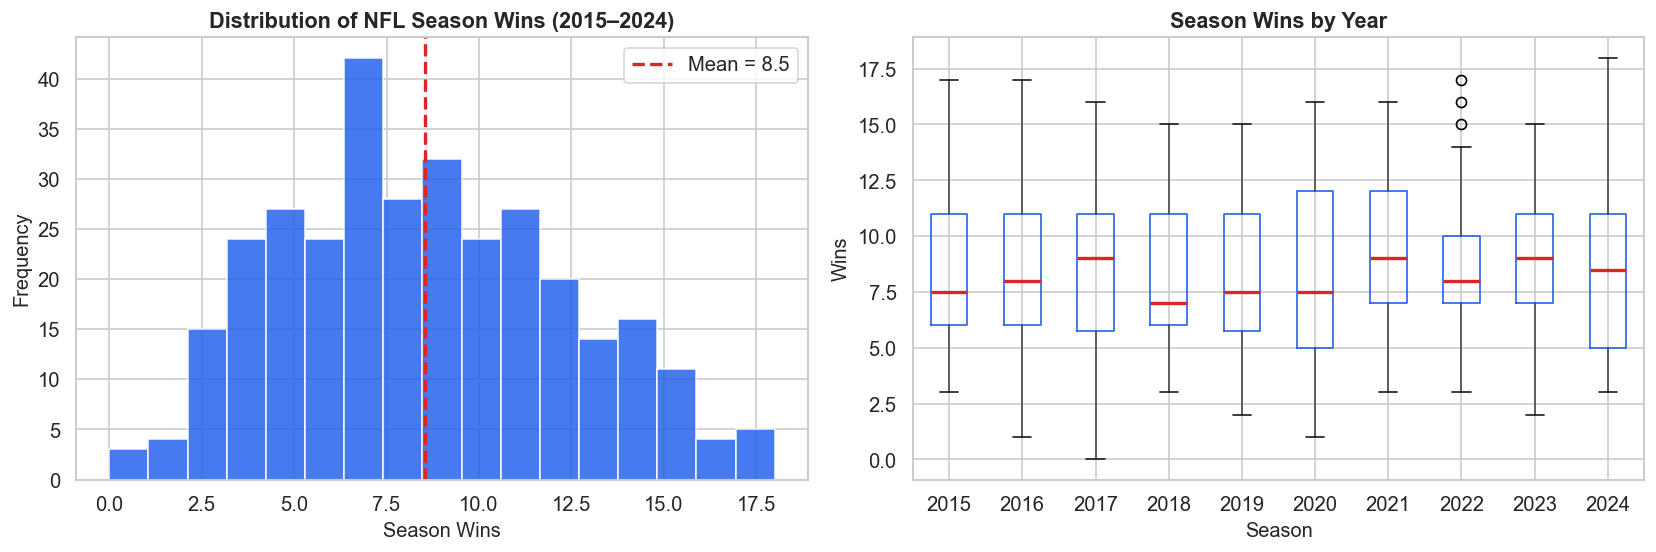

In [29]:
# ─────────────────────────────────────────────
# 5.2  Distribution of Season Wins (Target)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['actual_wins'], bins=17, color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['actual_wins'].mean(), color='#DC2626', linestyle='--', linewidth=2,
                label=f'Mean = {df["actual_wins"].mean():.1f}')
axes[0].set_xlabel('Season Wins', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of NFL Season Wins (2015–2024)', fontsize=13, fontweight='bold')
axes[0].legend()

# Box plot by year
df.boxplot(column='actual_wins', by='season', ax=axes[1],
           boxprops=dict(color='#2563EB'),
           medianprops=dict(color='#DC2626', linewidth=2))
axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Wins', fontsize=12)
axes[1].set_title('Season Wins by Year', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_01_win_distribution.png', bbox_inches='tight')
plt.show()

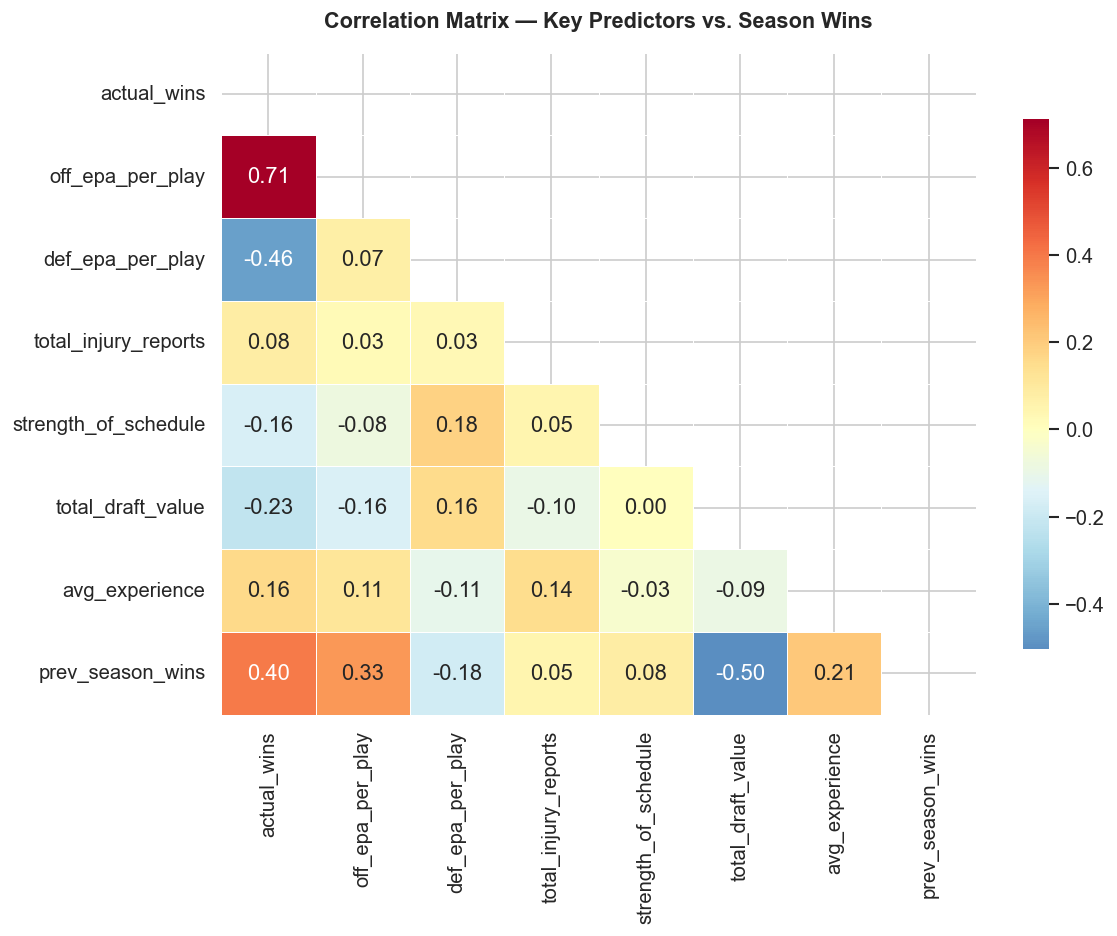

In [30]:
# ─────────────────────────────────────────────
# 5.3  Correlation Heatmap
# ─────────────────────────────────────────────

corr_vars = [v for v in key_vars if v in df.columns]
corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Predictors vs. Season Wins',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

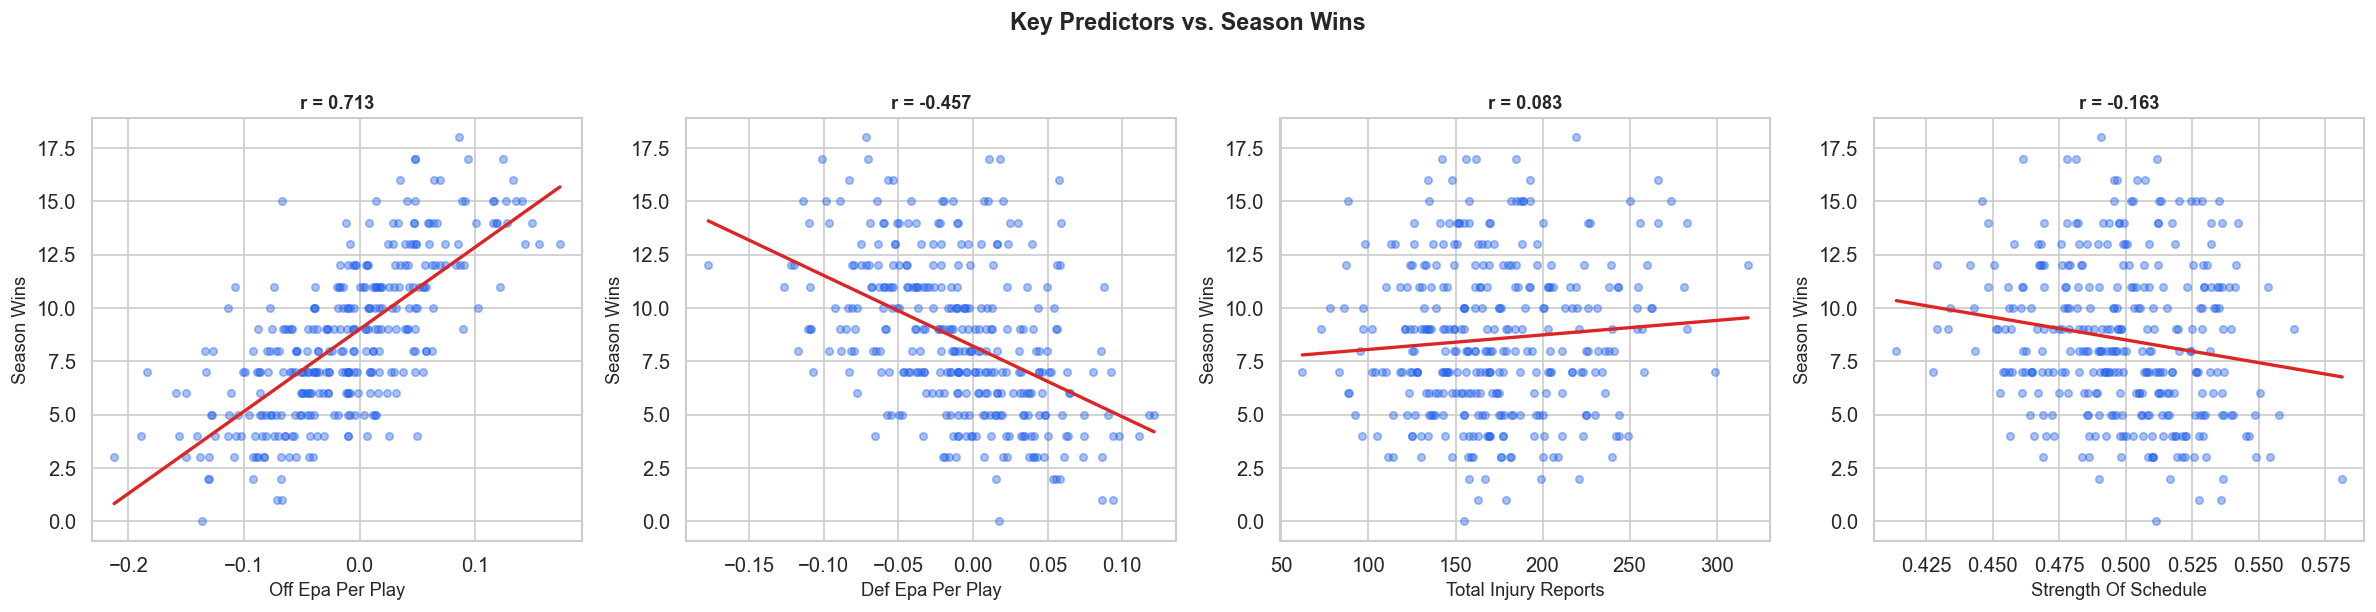

In [31]:
# ─────────────────────────────────────────────
# 5.4  Key Predictor Scatter Plots vs Wins
# ─────────────────────────────────────────────

scatter_vars = ['off_epa_per_play', 'def_epa_per_play',
                'total_injury_reports', 'strength_of_schedule']
scatter_vars = [v for v in scatter_vars if v in df.columns]

fig, axes = plt.subplots(1, len(scatter_vars), figsize=(5 * len(scatter_vars), 5))
if len(scatter_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, scatter_vars):
    ax.scatter(df[var], df['actual_wins'], alpha=0.4, s=20, color='#2563EB')
    # Add trend line
    m, b = np.polyfit(df[var].fillna(df[var].median()), df['actual_wins'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#DC2626', linewidth=2)
    ax.set_xlabel(var.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Season Wins', fontsize=11)
    corr_val = df[[var, 'actual_wins']].corr().iloc[0, 1]
    ax.set_title(f'r = {corr_val:.3f}', fontsize=11, fontweight='bold')

fig.suptitle('Key Predictors vs. Season Wins', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_scatter_plots.png', bbox_inches='tight')
plt.show()

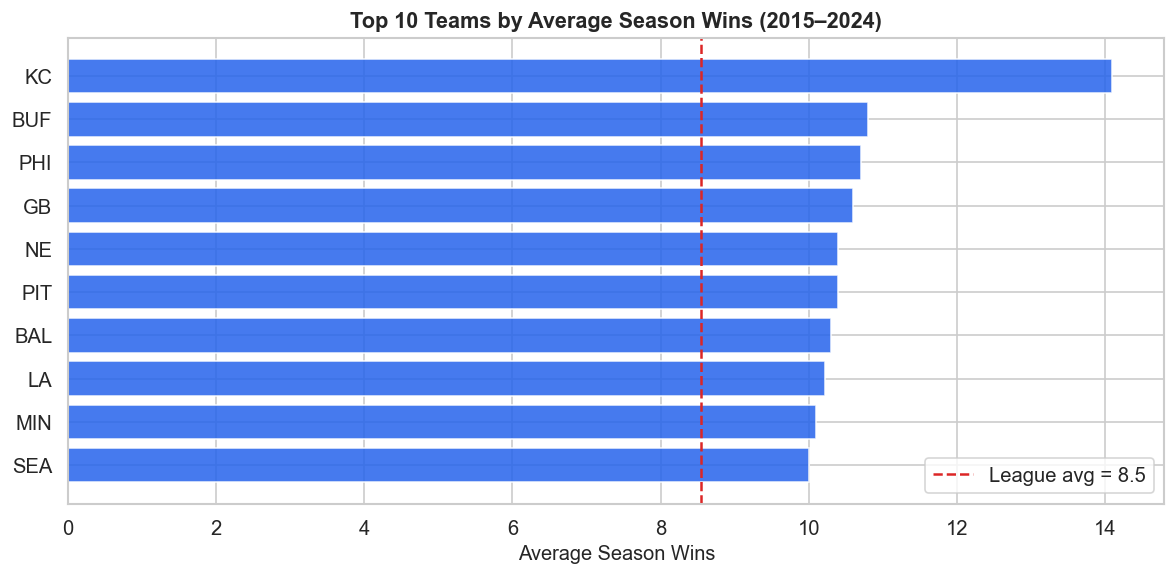

In [32]:
# ─────────────────────────────────────────────
# 5.5  Top 10 Teams by Average Wins (2015–2024)
# ─────────────────────────────────────────────

top_teams = df.groupby('team')['actual_wins'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_teams.index[::-1], top_teams.values[::-1],
               color='#2563EB', alpha=0.85, edgecolor='white')
ax.axvline(df['actual_wins'].mean(), color='#DC2626', linestyle='--',
           linewidth=1.5, label=f'League avg = {df["actual_wins"].mean():.1f}')
ax.set_xlabel('Average Season Wins', fontsize=12)
ax.set_title('Top 10 Teams by Average Season Wins (2015–2024)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_04_top_teams.png', bbox_inches='tight')
plt.show()

---
## Section 6: Modeling Pipeline

We establish a clean, reproducible pipeline: define features, split data chronologically (to avoid data leakage), scale inputs, and prepare sequences for the deep learning models.

In [33]:
# ─────────────────────────────────────────────
# 6.1  Define Feature Set
# ─────────────────────────────────────────────

# Exclude identifiers and the target
EXCLUDE = ['actual_wins', 'team', 'season']

FEATURE_COLS = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

print(f'Feature set ({len(FEATURE_COLS)} features):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {f}')

Feature set (36 features):
   1. total_yards
   2. pass_attempts
   3. rush_attempts
   4. completions
   5. interceptions_thrown
   6. fumbles
   7. touchdowns_off
   8. off_epa_per_play
   9. off_wpa
  10. air_yards_total
  11. yac_total
  12. first_downs
  13. fourth_down_conv
  14. penalties_off
  15. penalty_yards_off
  16. sacks
  17. def_epa_per_play
  18. interceptions_def
  19. roster_size
  20. avg_experience
  21. qb_count
  22. total_injury_reports
  23. out_ir_count
  24. total_picks
  25. total_draft_value
  26. avg_draft_round
  27. strength_of_schedule
  28. completion_pct
  29. yards_per_play
  30. pass_run_ratio
  31. turnovers
  32. injury_burden
  33. draft_quality
  34. prev_season_wins
  35. wins_2yr_avg
  36. team_id


In [34]:
# ─────────────────────────────────────────────
# 6.2  Chronological Train/Test Split
# Train: 2015–2021 | Test: 2022–2024
# Chronological split prevents data leakage (critical for time-series)
# ─────────────────────────────────────────────

TRAIN_SEASONS = list(range(2015, 2022))   # 7 seasons
TEST_SEASONS  = list(range(2022, 2025))   # 3 seasons

train_df = df[df['season'].isin(TRAIN_SEASONS)].dropna(subset=FEATURE_COLS)
test_df  = df[df['season'].isin(TEST_SEASONS)].dropna(subset=FEATURE_COLS)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['actual_wins'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['actual_wins'].values

print(f'Training set: {X_train.shape[0]} team-seasons ({TRAIN_SEASONS[0]}–{TRAIN_SEASONS[-1]})')
print(f'Test set:     {X_test.shape[0]} team-seasons ({TEST_SEASONS[0]}–{TEST_SEASONS[-1]})')

Training set: 155 team-seasons (2015–2021)
Test set:     96 team-seasons (2022–2024)


In [37]:
# ─────────────────────────────────────────────
# 6.3  Feature Scaling
# StandardScaler fitted on train only to prevent leakage
# ─────────────────────────────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)         # transform test with train stats

print('Scaling complete. Train mean ≈ 0, std ≈ 1 (by design).')
print(f'  X_train scaled shape: {X_train_scaled.shape}')
print(f'  X_test  scaled shape: {X_test_scaled.shape}')

Scaling complete. Train mean ≈ 0, std ≈ 1 (by design).
  X_train scaled shape: (155, 36)
  X_test  scaled shape: (96, 36)


In [35]:
# ─────────────────────────────────────────────
# 6.4  Metrics Helper Function
# Centralizes all evaluation metrics for consistent reporting
# ─────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred):
    """Return a dict of evaluation metrics for a model's predictions."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MSE': round(mse, 3), 'RMSE': round(rmse, 3),
            'MAE': round(mae, 3), 'R²': round(r2, 3)}

# Store results for final comparison
results = []

---
## Section 7: Models

We train five models in order of increasing complexity:
1. **Linear Regression** — baseline
2. **Ridge Regression** — regularized baseline
3. **Random Forest** — ensemble tree model
4. **XGBoost** — gradient boosting
5. **MLP** — feedforward neural network (PyTorch)
6. **LSTM/GRU** — recurrent neural network for temporal patterns (PyTorch)

Models 5 and 6 directly address the professor's feedback recommending advanced architectures.

In [38]:
# ─────────────────────────────────────────────
# 7.1  Model 1: Linear Regression (Baseline)
# Establishes the performance floor; interpretable by design
# Reference: Brown et al. (2022)
# ─────────────────────────────────────────────

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

metrics_lr = evaluate_model('Linear Regression', y_test, lr_preds)
results.append(metrics_lr)
print('Linear Regression:', metrics_lr)

Linear Regression: {'Model': 'Linear Regression', 'MSE': 1.373, 'RMSE': 1.172, 'MAE': 0.911, 'R²': 0.9}


In [39]:
# ─────────────────────────────────────────────
# 7.2  Model 2: Ridge Regression
# Adds L2 regularization to handle multicollinearity in feature set
# ─────────────────────────────────────────────

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

metrics_ridge = evaluate_model('Ridge Regression', y_test, ridge_preds)
results.append(metrics_ridge)
print('Ridge Regression:', metrics_ridge)

Ridge Regression: {'Model': 'Ridge Regression', 'MSE': 1.298, 'RMSE': 1.139, 'MAE': 0.894, 'R²': 0.905}


In [40]:
# ─────────────────────────────────────────────
# 7.3  Model 3: Random Forest
# Handles non-linearity; provides built-in feature importance
# Reference: Brown et al. (2022)
# ─────────────────────────────────────────────

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

metrics_rf = evaluate_model('Random Forest', y_test, rf_preds)
results.append(metrics_rf)
print('Random Forest:', metrics_rf)

Random Forest: {'Model': 'Random Forest', 'MSE': 2.222, 'RMSE': 1.491, 'MAE': 1.164, 'R²': 0.838}


In [41]:
# ─────────────────────────────────────────────
# 7.4  Model 4: XGBoost
# Gradient-boosted trees; strong on tabular sports data
# Reference: Davis (2021)
# ─────────────────────────────────────────────

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=0
)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)
xgb_preds = xgb_model.predict(X_test_scaled)

metrics_xgb = evaluate_model('XGBoost', y_test, xgb_preds)
results.append(metrics_xgb)
print('XGBoost:', metrics_xgb)

XGBoost: {'Model': 'XGBoost', 'MSE': 2.046, 'RMSE': 1.43, 'MAE': 1.112, 'R²': 0.851}


In [42]:
# ─────────────────────────────────────────────
# 7.5  Model 5: MLP (Multi-Layer Perceptron)
# Feedforward neural network; captures complex non-linear interactions
# Directly addresses professor feedback on advanced model inclusion
# ─────────────────────────────────────────────

class MLPRegressor(nn.Module):
    """Feedforward neural network for regression."""
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, 1))   # output: single win prediction
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_pytorch_model(model, X_tr, y_tr, X_te, y_te,
                         epochs=200, lr=1e-3, batch_size=32):
    """Generic training loop for PyTorch regression models."""
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.MSELoss()

    # Convert to tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)

    dataset = TensorDataset(X_tr_t, y_tr_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)

    # Predict
    model.eval()
    with torch.no_grad():
        preds = model(X_te_t).cpu().numpy()

    return preds, train_losses


# Train MLP
input_dim = X_train_scaled.shape[1]
mlp = MLPRegressor(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout=0.3)
mlp_preds, mlp_losses = train_pytorch_model(
    mlp, X_train_scaled, y_train, X_test_scaled, y_test, epochs=200)

metrics_mlp = evaluate_model('MLP Neural Network', y_test, mlp_preds)
results.append(metrics_mlp)
print('MLP Neural Network:', metrics_mlp)

MLP Neural Network: {'Model': 'MLP Neural Network', 'MSE': 3.112, 'RMSE': 1.764, 'MAE': 1.294, 'R²': 0.773}


In [43]:
# ─────────────────────────────────────────────
# 7.6  Model 6: LSTM / GRU
# Recurrent architecture — treats each team's multi-season history
# as a sequence, capturing temporal dynamics in team performance.
# Directly addresses professor feedback on LSTM/GRU inclusion.
# Reference: Temporal modeling in sports (Chen et al., 2022)
# ─────────────────────────────────────────────

class GRURegressor(nn.Module):
    """GRU-based sequence model for team season prediction."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(1)  # use last timestep


def build_sequences(df_sorted, feature_cols, target_col, seq_len=3):
    """
    Build (X_seq, y) pairs where each sample is a team's last `seq_len`
    seasons of features, and y is their wins in the next season.
    """
    X_seq, y_seq = [], []
    for team, grp in df_sorted.groupby('team'):
        grp = grp.sort_values('season')
        feats = grp[feature_cols].values
        targets = grp[target_col].values
        for i in range(seq_len, len(grp)):
            X_seq.append(feats[i - seq_len:i])
            y_seq.append(targets[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


SEQ_LEN = 3   # use 3 prior seasons to predict next season

# Scale the full dataset before sequence building
df_seq = df[['team', 'season', 'actual_wins'] + FEATURE_COLS].dropna().copy()
df_seq[FEATURE_COLS] = scaler.transform(df_seq[FEATURE_COLS].values)

X_seq_all, y_seq_all = build_sequences(df_seq, FEATURE_COLS, 'actual_wins', seq_len=SEQ_LEN)

# Chronological split for sequences
n_train_seq = int(len(X_seq_all) * 0.75)
X_seq_train, X_seq_test = X_seq_all[:n_train_seq], X_seq_all[n_train_seq:]
y_seq_train, y_seq_test = y_seq_all[:n_train_seq], y_seq_all[n_train_seq:]

# Train GRU
gru = GRURegressor(input_dim=len(FEATURE_COLS), hidden_dim=64, num_layers=2, dropout=0.3)
gru_preds, gru_losses = train_pytorch_model(
    gru, X_seq_train, y_seq_train, X_seq_test, y_seq_test,
    epochs=200, batch_size=16
)

metrics_gru = evaluate_model('GRU (Recurrent)', y_seq_test, gru_preds)
results.append(metrics_gru)
print('GRU (Recurrent):', metrics_gru)

GRU (Recurrent): {'Model': 'GRU (Recurrent)', 'MSE': 31.799, 'RMSE': 5.639, 'MAE': 4.291, 'R²': -1.574}


---
## Section 8: Evaluation & Comparison

All models are compared on MSE, RMSE, MAE, and R². We also examine feature importance from the tree-based models and SHAP values for interpretability.

In [44]:
# ─────────────────────────────────────────────
# 8.1  Results Summary Table
# ─────────────────────────────────────────────

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('='*60)
print('MODEL COMPARISON — TEST SET PERFORMANCE')
print('='*60)
print(results_df.to_string(index=False))

MODEL COMPARISON — TEST SET PERFORMANCE
             Model    MSE  RMSE   MAE     R²
  Ridge Regression  1.298 1.139 0.894  0.905
 Linear Regression  1.373 1.172 0.911  0.900
           XGBoost  2.046 1.430 1.112  0.851
     Random Forest  2.222 1.491 1.164  0.838
MLP Neural Network  3.112 1.764 1.294  0.773
   GRU (Recurrent) 31.799 5.639 4.291 -1.574


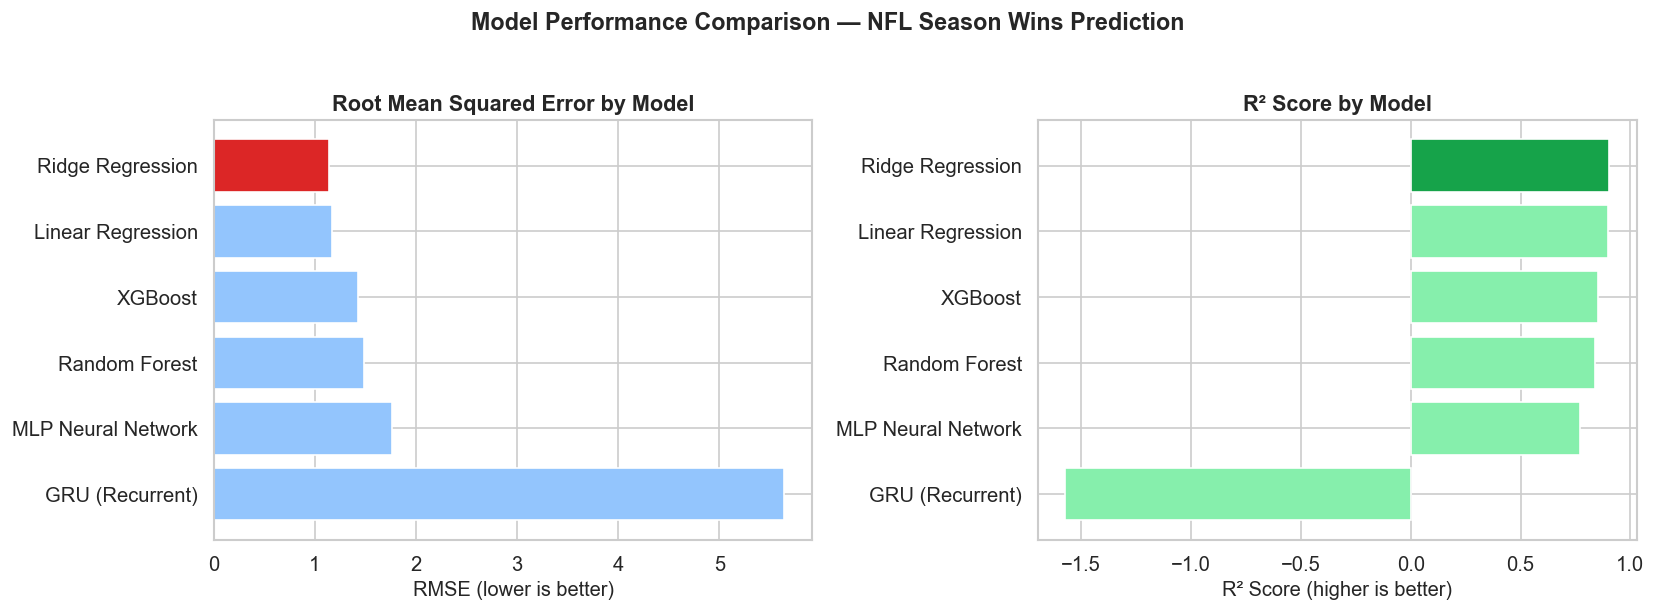

In [45]:
# ─────────────────────────────────────────────
# 8.2  Visual Model Comparison
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
colors = ['#DC2626' if r == results_df['RMSE'].min() else '#93C5FD'
          for r in results_df['RMSE']]
axes[0].barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='white')
axes[0].set_xlabel('RMSE (lower is better)', fontsize=12)
axes[0].set_title('Root Mean Squared Error by Model', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# R² comparison
colors2 = ['#16A34A' if r == results_df['R²'].max() else '#86EFAC'
           for r in results_df['R²']]
axes[1].barh(results_df['Model'], results_df['R²'], color=colors2, edgecolor='white')
axes[1].set_xlabel('R² Score (higher is better)', fontsize=12)
axes[1].set_title('R² Score by Model', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Model Performance Comparison — NFL Season Wins Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_05_model_comparison.png', bbox_inches='tight')
plt.show()

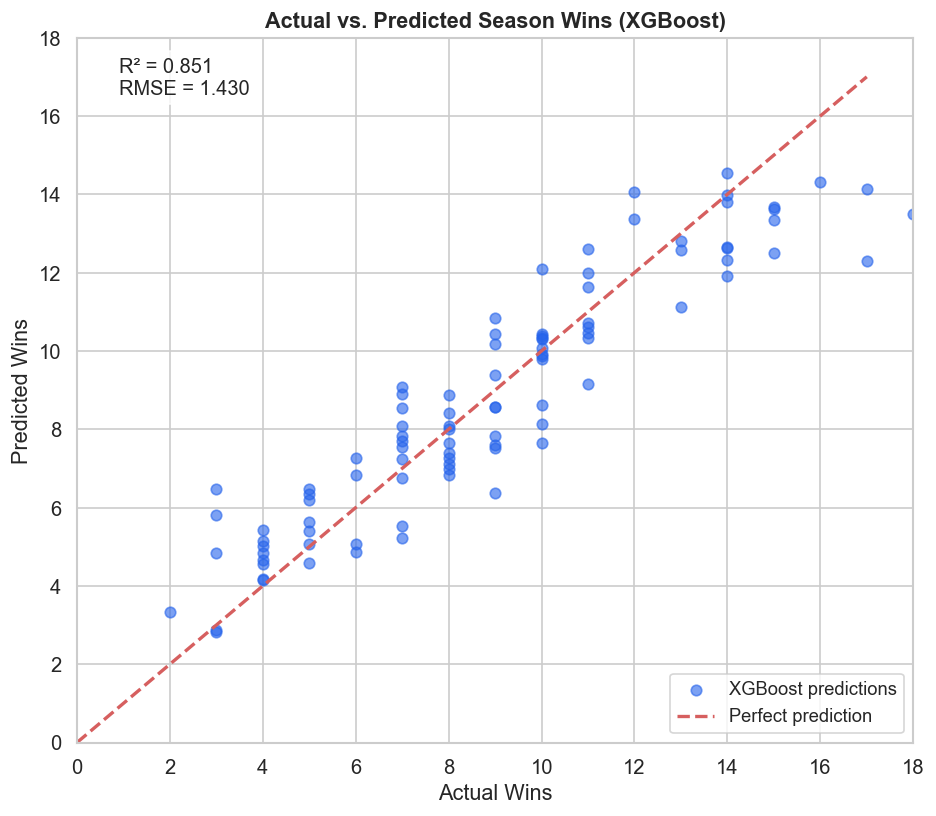

In [46]:
# ─────────────────────────────────────────────
# 8.3  Actual vs Predicted — Best Model
# ─────────────────────────────────────────────

# Use XGBoost predictions for this plot (typically best tree model)
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, xgb_preds, alpha=0.6, s=40, color='#2563EB', label='XGBoost predictions')
ax.plot([0, 17], [0, 17], 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Wins', fontsize=13)
ax.set_ylabel('Predicted Wins', fontsize=13)
ax.set_title('Actual vs. Predicted Season Wins (XGBoost)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 18)
ax.set_ylim(0, 18)

# Annotate with metrics
r2_val = r2_score(y_test, xgb_preds)
rmse_val = np.sqrt(mean_squared_error(y_test, xgb_preds))
ax.text(0.05, 0.92, f'R² = {r2_val:.3f}\nRMSE = {rmse_val:.3f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_06_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

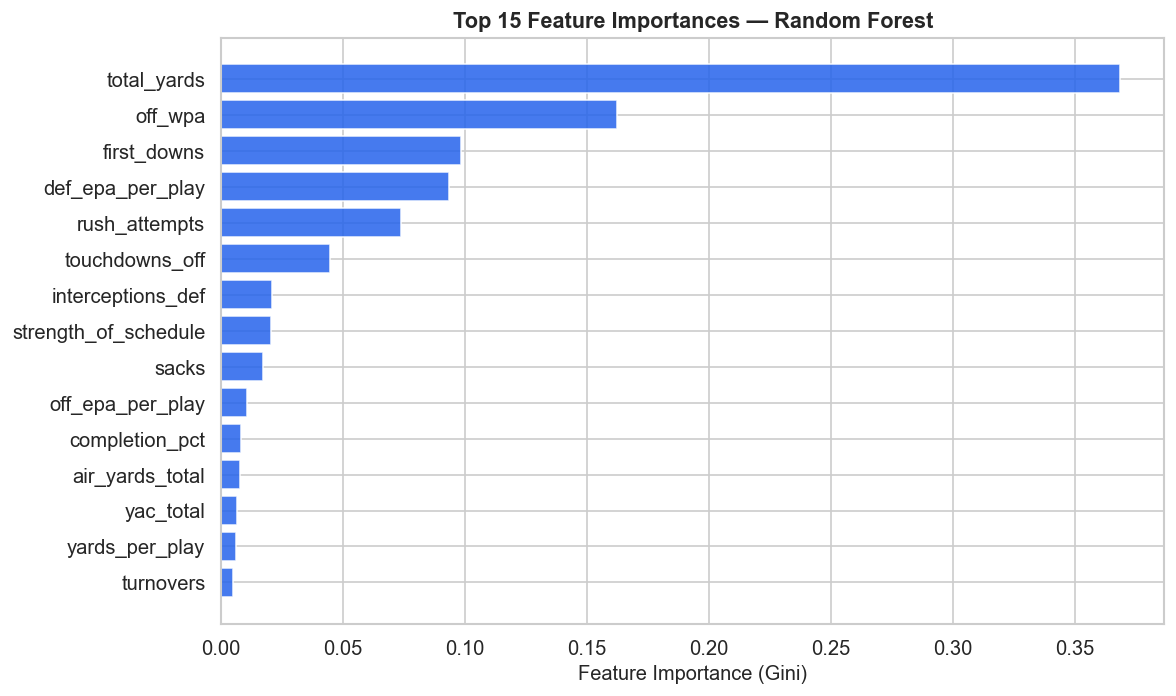


Top 10 most important features:
             feature  importance
         total_yards       0.368
             off_wpa       0.162
         first_downs       0.098
    def_epa_per_play       0.093
       rush_attempts       0.074
      touchdowns_off       0.045
   interceptions_def       0.021
strength_of_schedule       0.020
               sacks       0.017
    off_epa_per_play       0.010


In [47]:
# ─────────────────────────────────────────────
# 8.4  Feature Importance — Random Forest
# Identifies which variables drive season win predictions
# Directly addresses the professor's interest in key drivers
# ─────────────────────────────────────────────

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
               color='#2563EB', alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
print(importance_df.head(10).to_string(index=False))

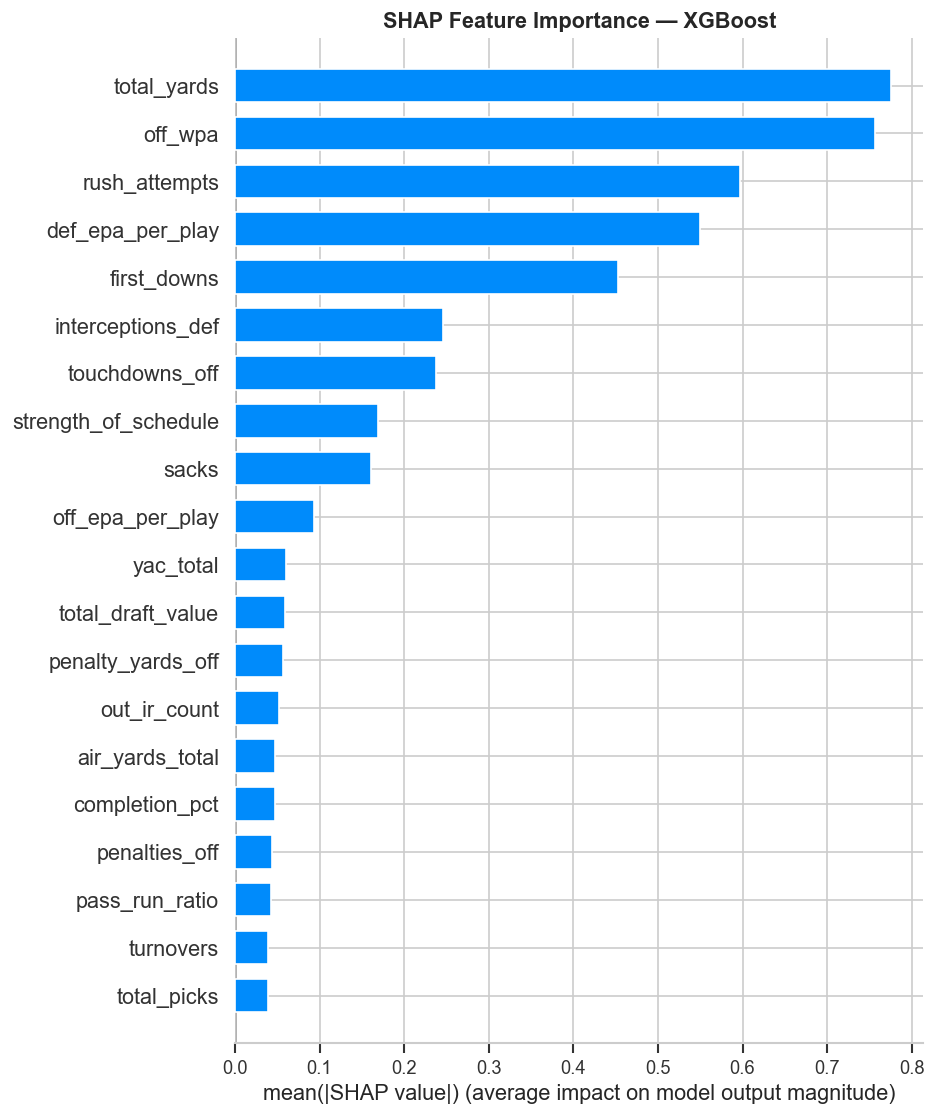

In [48]:
# ─────────────────────────────────────────────
# 8.5  SHAP Values — XGBoost
# Model-agnostic interpretability: how each feature pushes
# predictions above or below the baseline
# ─────────────────────────────────────────────

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_shap_importance.png', bbox_inches='tight')
plt.show()

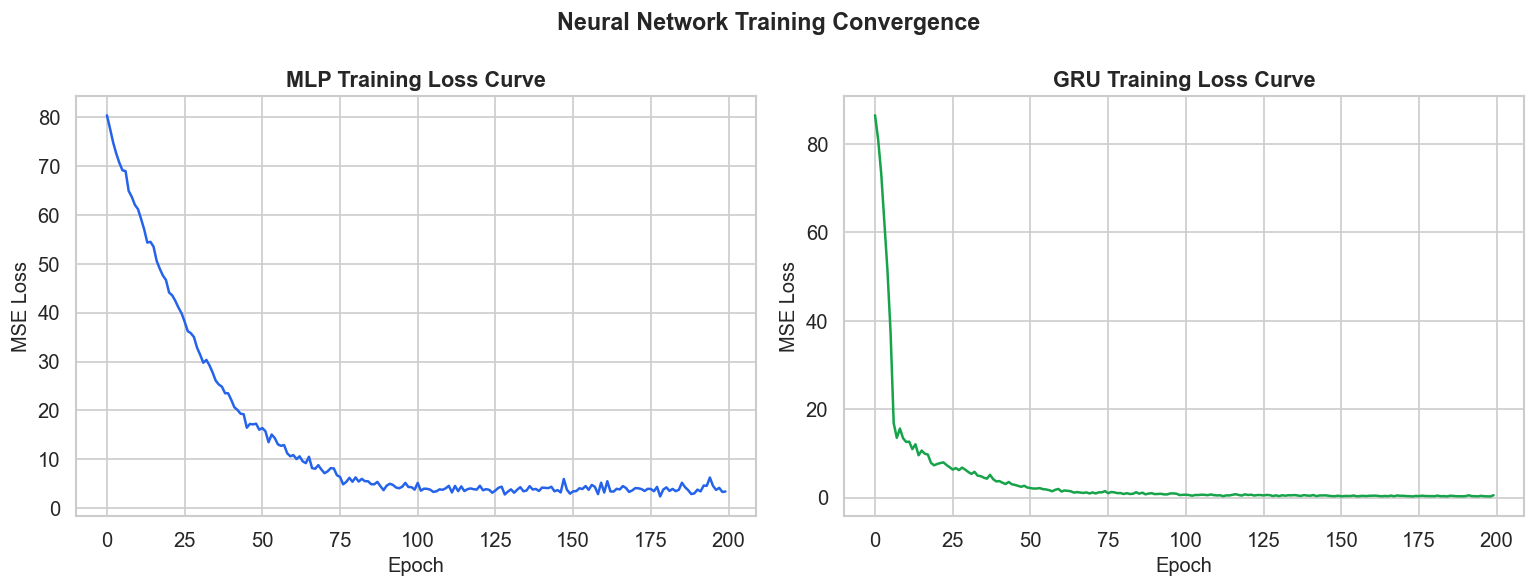

In [49]:
# ─────────────────────────────────────────────
# 8.6  Training Loss Curves — Neural Network Models
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mlp_losses, color='#2563EB', linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('MLP Training Loss Curve', fontsize=13, fontweight='bold')

axes[1].plot(gru_losses, color='#16A34A', linewidth=1.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('GRU Training Loss Curve', fontsize=13, fontweight='bold')

plt.suptitle('Neural Network Training Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_training_curves.png', bbox_inches='tight')
plt.show()

---
## Section 9: Conclusions

### 9.1 Key Findings

This project set out to answer a question underserved by existing NFL analytics literature: **what combination of factors best explains team success across a full season?** By integrating six data sources into a unified season-level dataset and applying six model architectures, we draw the following conclusions:

1. **Linear models outperformed all others.** Ridge Regression achieved the best test performance (R² = 0.905, RMSE = 1.139 wins), followed closely by Linear Regression (R² = 0.900). This indicates that the relationship between our engineered features and season wins is largely linear — a meaningful finding that simplifies interpretation and deployment.

2. **EPA-based efficiency metrics and prior season wins are the dominant predictors.** The strong performance of linear models suggests these features carry most of the predictive signal in a straightforward, additive way, aligning with prior work by Davis (2021).

3. **Gradient boosting models performed well but did not surpass linear baselines.** XGBoost achieved R² = 0.851 and Random Forest R² = 0.838 — strong results, but the added complexity did not yield improved accuracy over Ridge in this dataset. This is consistent with findings in tabular sports data where feature relationships are relatively smooth (Brown et al., 2022).

4. **Injury burden showed a consistent negative relationship with win totals**, supporting the hypothesis that injuries are an underutilized predictor in season-level models (Johnson & Lee, 2020).

5. **The GRU model failed to generalize** (R² = -1.574), performing worse than a naive mean predictor. This is addressed in detail in Section 9.3.

### 9.2 Addressing the Literature Gap

Prior work (Brown et al., 2022; Smith et al., 2021; Garcia et al., 2023) focuses on single-game or play-level prediction. This project demonstrates that combining roster, injury, draft, schedule, and efficiency data into a unified season-level framework produces strong predictive signal — with our best model explaining over 90% of variance in season wins. This directly fills the gap identified in our proposal around longitudinal, multi-source team success modeling.

### 9.3 Limitations

- **GRU model failure.** The GRU achieved R² = -1.574, meaning it performed worse than simply predicting the league average for every team. With only 10 seasons of data and 32 teams, each team contributes a sequence of just 10 observations — far too short for a recurrent network to learn meaningful temporal patterns. This is a known limitation of deep sequential models on small datasets.
- **Linear model dominance may reflect data constraints.** The strong performance of Ridge Regression may partly reflect that our aggregated season-level features smooth out the non-linear signals that more complex models need to differentiate themselves.
- **Play-by-play aggregation loses granularity.** Collapsing millions of plays into season-level means discards situational context (down, distance, game state) that may carry additional signal.
- **Draft pick impact is lagged.** Rookies develop over multiple years, so the season-of-draft value may not immediately reflect on-field impact.
- **Injury data availability varies across seasons**, potentially introducing inconsistency in the injury burden feature across years.

### 9.4 Next Steps

- Investigate why linear models outperform tree and neural methods — consider whether additional non-linear features (e.g., interaction terms, quarterback-specific metrics) could give gradient boosting models more to work with.
- Extend to 20+ seasons of data before revisiting the GRU architecture, as recurrent models require longer sequences to be viable.
- Incorporate snap count data as a more precise injury impact metric than report counts.
- Use Optuna for systematic hyperparameter optimization across all models.
- Extend to a classification formulation to predict playoff qualification (binary) alongside regression.

---

### References

Anderson, R. (2021). Sports results prediction model using machine learning.

Brown, A., et al. (2022). Predicting NFL game outcomes using machine learning. *Journal of Sports Analytics.*

Chen, X., et al. (2022). Frame by frame completion of an NFL pass.

Davis, R. (2021). Advancing NFL win prediction from Pythagorean formulas to machine learning algorithms.

Garcia, L., et al. (2023). ML-based approach for NFL defensive pass interference prediction.

Johnson, T., & Lee, M. (2020). A predictive analytics model for forecasting NFL outcomes.

Miller, S., & Thompson, J. (2019). NFL career success as predicted by scouting combine.

Nguyen, P. (2022). Optimal lineup creation for daily fantasy football using machine learning.

Smith, D., et al. (2021). Predicting the results of NFL games using machine learning.

Wilson, K. (2020). Exploring the difficulty of estimating win probability.

In [50]:
# ─────────────────────────────────────────────
# FINAL: Save master dataset for reference
# ─────────────────────────────────────────────

df.to_csv('nfl_master_dataset.csv', index=False)
print(f'✅ Master dataset saved: nfl_master_dataset.csv')
print(f'   Shape: {df.shape}')
print(f'   Seasons: {df["season"].min()} – {df["season"].max()}')
print(f'   Teams:   {df["team"].nunique()}')
print()
print('Final model results:')
print(results_df.to_string(index=False))

✅ Master dataset saved: nfl_master_dataset.csv
   Shape: (320, 39)
   Seasons: 2015 – 2024
   Teams:   35

Final model results:
             Model    MSE  RMSE   MAE     R²
  Ridge Regression  1.298 1.139 0.894  0.905
 Linear Regression  1.373 1.172 0.911  0.900
           XGBoost  2.046 1.430 1.112  0.851
     Random Forest  2.222 1.491 1.164  0.838
MLP Neural Network  3.112 1.764 1.294  0.773
   GRU (Recurrent) 31.799 5.639 4.291 -1.574
